# Proyek Analisis Data: [Bike Sharing Analyst]
- **Nama:** [Adita Eka Pratama]
- **Email:** [apratama25064@gmail.com]
- **ID Dicoding:** [Adita Eka Pratama]

## Menentukan Pertanyaan Bisnis

What are the types of Bike Sharing users on a daily basis?
How productive is Bike Sharing in 24 hours?
How productive is Bike Sharing on a monthly basis?
How do weather and seasons affect Bike Sharing productivity?

## Import Semua Packages/Library yang Digunakan

In [209]:
%%bash
# conda create --name main-ds python=3.9
# conda activate main-ds
# pip install -r requirements.txt

In [210]:
%%bash
pip install pandas
pip install numpy
pip install matplotlib
pip install seaborn
pip install scipy
pip install jupyter


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [211]:
%%bash
pip install Streamlit


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [212]:
%%bash
mkdir -p data
cd data
# pipenv install
# pipenv shell
# pip install -r requirements.txt

In [213]:
%%writefile Dasboard/dashboard.py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st
from babel.numbers import format_currency
sns.set(style='dark')

# Helper functions

def create_daily_orders_df(df):
    df['date'] = pd.to_datetime(df['date'])
    orders_df = df.resample('M', on='date').sum()
    return orders_df

def create_sum_casual_user_df(df):
    sum_casual_user_df = df.groupby("day").casual_user.sum().sort_values(ascending=False).reset_index()
    return sum_casual_user_df

def create_sum_registered_user_df(df):
    sum_registered_user_df = df.groupby("day").registered_User.sum().sort_values(ascending=False).reset_index()
    return sum_registered_user_df

def create_byweather_df(df):
    byweather_df = df.groupby("weather").total_user.sum().sort_values(ascending=False).reset_index()
    return byweather_df

def create_byseason_df(df):
    byseason_df = df.groupby("season").total_user.sum().sort_values(ascending=False).reset_index()
    return byseason_df

def create_rfm_df(df):
    rfm_df = df.groupby(by="day", as_index=False).agg({
        "date": "max",
        "instant": "nunique",
        "total_user": "sum"
    })
    rfm_df.columns = ["day", "max_order_timestamp", "frequency", "monetary"]
    rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
    recent_date = df["date"].dt.date.max()
    rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)
    rfm_df.drop("max_order_timestamp", axis=1, inplace=True)
    return rfm_df


# Prepare dataframe
day_df = pd.read_csv("Dashboard/day_clean.csv")

# Ensure the date column are of type datetime
datetime_columns = ["date"]
day_df.sort_values(by="date", inplace=True)
day_df.reset_index(inplace=True)
for column in datetime_columns:
    day_df[column] = pd.to_datetime(day_df[column])

# Create filter components
min_date = day_df["date"].min()
max_date = day_df["date"].max()

with st.sidebar:
    # Adding a company logo
    st.image("dashboard/logo.png") # Assuming you have a logo.png in the dashboard directory

    # Retrieve start_date & end_date from date_input
    start_date, end_date = st.date_input(
        label='Range of Time', min_value=min_date,
        max_value=max_date,
        value=[min_date, max_date]
    )

main_df = day_df[(day_df["date"] >= str(start_date)) &
                (day_df["date"] <= str(end_date))]

daily_orders_df = create_daily_orders_df(main_df)
sum_casual_user_df = create_sum_casual_user_df(main_df)
sum_registered_user_df = create_sum_registered_user_df(main_df)
byweather_df = create_byweather_df(main_df)
byseason_df = create_byseason_df(main_df)
rfm_df = create_rfm_df(main_df)

# Create dashboard
st.header('Capital Bike Share Dashboard :sparkles:')

# Daily Users
st.subheader('Daily Users')
col1, col2, col3 = st.columns(3)

with col1:
    total_casual = daily_orders_df.casual_user.sum()
    st.metric("Total Casual User", value=f'{total_casual:,}')

with col2:
    total_registered = daily_orders_df.registered_User.sum()
    st.metric("Total Registered User", value=f'{total_registered:,}')

with col3:
    total_users = daily_orders_df.total_user.sum()
    st.metric("Total Users", value=f'{total_users:,}')

plt.figure(figsize=(10, 6))
plt.plot(daily_orders_df.index, daily_orders_df['total_user'], color='#A5C0DD')
plt.xlabel(None)
plt.ylabel(None)
plt.title('Number of Users')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
st.pyplot(plt)

# Number of Casual Users and Registered Users by Day
st.subheader("Number of Casual Users and Registered Users by Day")
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(35, 15))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="casual_user", y="day", data=sum_casual_user_df, palette=colors, hue="day", legend=False, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Casual User", loc="center", fontsize=50)
ax[0].tick_params(axis ='y', labelsize=30)
ax[0].tick_params(axis ='x', labelsize=30, rotation=45)

sns.barplot(x="registered_User", y="day", data=sum_registered_user_df, palette=colors, hue="day", legend=False, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Registered User", loc="center", fontsize=50)
ax[1].tick_params(axis='y', labelsize=30)
ax[1].tick_params(axis ='x', labelsize=30, rotation=-45)

st.pyplot(fig)

# The Effect of Weather and Season on Bike Sharing Productivity
st.subheader("Number of Users by Weather and Season")
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(35, 15))
sns.barplot(y="total_user", x="weather", data=byweather_df.sort_values(by="total_user", ascending=False), palette=colors, hue="weather", legend=False, ax=ax[0])
ax[0].set_title("Number of User by Weather", loc="center", fontsize=50)
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].tick_params(axis ='y', labelsize=30)
ax[0].tick_params(axis ='x', labelsize=30)
ax[0].ticklabel_format(style='plain', axis='y')

sns.barplot(y="total_user", x="season", data=byseason_df.sort_values(by="total_user", ascending=False), palette=colors, hue="season", legend=False, ax=ax[1])
ax[1].set_title("Number of User by Season", loc="center", fontsize=50)
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].tick_params(axis='y', labelsize=30)
ax[1].tick_params(axis ='x', labelsize=30)
ax[1].ticklabel_format(style='plain', axis='y')

st.pyplot(fig)

# RFM Analysis
st.subheader("Best Customer Based on RFM Parameters (day)")
col1, col2, col3 = st.columns(3)

with col1:
    avg_recency = round(rfm_df.recency.mean(), 1)
    st.metric("Average Recency (days)", value=avg_recency)

with col2:
    avg_frequency = round(rfm_df.frequency.mean(), 2)
    st.metric("Average Frequency", value=avg_frequency)

with col3:
    avg_frequency = format_currency(rfm_df.monetary.mean(), "AUD", locale='es_CO')
    st.metric("Average Monetary", value=avg_frequency)

fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(35, 15))
colors = ["#90CAF9", "#90CAF9", "#90CAF9", "#90CAF9", "#90CAF9"]

sns.barplot(y="recency", x="day", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, hue="day", legend=False, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=50)
ax[0].tick_params(axis='y', labelsize=25)
ax[0].tick_params(axis ='x', labelsize=30, rotation=45)

sns.barplot(y="frequency", x="day", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, hue="day", legend=False, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=50)
ax[1].tick_params(axis='y', labelsize=25)
ax[1].tick_params(axis='x', labelsize=30, rotation=45)

sns.barplot(y="monetary", x="day", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, hue="day", legend=False, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=50)
ax[2].tick_params(axis='y', labelsize=25)
ax[2].tick_params(axis='x', labelsize=30, rotation=45)

st.pyplot(fig)

Overwriting Dasboard/dashboard.py


In [214]:
%%writefile README.MD
# Data Analyst Project : Bike Sharing Dataset

## About Bike Sharing Dataset

[**Bike Sharing Dataset**](https://www.kaggle.com/datasets/lakshmi25npathi/bike-sharing-dataset) is a dataset that contains the hourly and daily count of rental bikes between the years 2011 and 2012 in the [**Capital Bikeshare**](https://capitalbikeshare.com) system with the corresponding weather and seasonal information.

**Dataset Information**

- instant: record index
- dteday : date
- season : season (1:springer, 2:summer, 3:fall, 4:winter)
- yr : year (0: 2011, 1:2012)
- mnth : month ( 1 to 12)
- hr : hour (0 to 23)
- holiday : weather day is holiday or not (extracted from [Web Link])
- weekday : day of the week
- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
- weathersit :
  - Clear, Few clouds, Partly cloudy, Partly cloudy
  - Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
  - Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
  - Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
- temp : Normalized temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-8, t_max=+39 (only in hourly scale)
- atemp: Normalized feeling temperature in Celsius. The values are derived via (t-t_min)/(t_max-t_min), t_min=-16, t_max=+50 (only in hourly scale)
- hum: Normalized humidity. The values are divided to 100 (max)
- windspeed: Normalized wind speed. The values are divided to 67 (max)
- casual: count of casual users
- registered: count of registered users
- cnt: count of total rental bikes including both casual and registered

## How to Run This Project ?

1. Clone this repository

```
git clone https://github.com/adityapratama1999/Bike_Sharing_Analyst
```

2. Install all library

```
pip install numpy pandas matplotlib seaborn jupyter streamlit babel
```

or

```
pip install -r requirements.txt
```

3. Go to dashboard folder

```
cd dashboard
```

4. Run with Streamlit

```
streamlit run dashboard.py
```

Overwriting README.MD


In [215]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [216]:
day_df = pd.read_csv('data/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Menampilkan Data set Dari File Csv.

In [217]:
hour_df = pd.read_csv('data/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Menampilkan Data Set Dari File Csv.

### Assessing Data

- instant: record index
	- dteday : date
	- season : season (1:springer, 2:summer, 3:fall, 4:winter)
	- yr : year (0: 2011, 1:2012)
	- mnth : month ( 1 to 12)
	- hr : hour (0 to 23)
	- holiday : weather day is holiday or not (extracted from http://dchr.dc.gov/page/holiday-schedule)
	- weekday : day of the week
	- workingday : if day is neither weekend nor holiday is 1, otherwise is 0.
	+ weathersit :
		- 1: Clear, Few clouds, Partly cloudy, Partly cloudy
		- 2: Mist + Cloudy, Mist + Broken clouds, Mist + Few clouds, Mist
		- 3: Light Snow, Light Rain + Thunderstorm + Scattered clouds, Light Rain + Scattered clouds
		- 4: Heavy Rain + Ice Pallets + Thunderstorm + Mist, Snow + Fog
	- temp : Normalized temperature in Celsius. The values are divided to 41 (max)
	- atemp: Normalized feeling temperature in Celsius. The values are divided to 50 (max)
	- hum: Normalized humidity. The values are divided to 100 (max)
	- windspeed: Normalized wind speed. The values are divided to 67 (max)
	- casual: count of casual users
	- registered: count of registered users
	- cnt: count of total rental bikes including both casual and registered


**1. DATA FRAME DAY**

displaying unmodified frame data day

In [218]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


If you pay attention, there are no problems with the data type, but there are some oddities in the column. There are several columns that need to be renamed from:
1. dteday becomes day
2. yr becomes years
3. mnth becomes month
4. weekday becomes day
5. weathersit becomes weather
6. tmp becomes temperature
7. atemp becomes temperature_feel
8. hum becomes humidity
9. casual becomes casual_user
10. registered becomes register_user
11. cnt becomes total_userDisplays renamed data  in columns
1. dteday becomes day
2. yr becomes years
3. mnth becomes month
4. weekday becomes day
5. weathersit becomes weather
6. tmp becomes temperature
7. atemp becomes temperature_feel
8. hum becomes humidity
9. casual becomes casual_user
10. registered becomes register_user
11. cnt becomes total_user





In [219]:
print('Number of duplications: ', day_df.duplicated().sum())
day_df.describe()

Number of duplications:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**2. Data Frame Hour**

displays unmodified frame hour data

In [220]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [221]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- xxx
- xxx

### Cleaning Data

**1. DATA FRAME DAY**

delete unused holiday columns

In [222]:
day_df.drop(['holiday'], axis=1, inplace=True)

Displays renamed data in columns
1. dteday becomes day
2. yr becomes years
3. mnth becomes month
4. weekday becomes day
5. weathersit becomes weather
6. tmp becomes temperature
7. atemp becomes temperature_feel
8. hum becomes humidity
9. casual becomes casual_user
10. registered becomes register_user
11. cnt becomes total_userDisplays renamed data  in columns
1. dteday becomes day
2. yr becomes years
3. mnth becomes month
4. weekday becomes day
5. weathersit becomes weather
6. tmp becomes temperature
7. atemp becomes temperature_feel
8. hum becomes humidity
9. casual becomes casual_user
10. registered becomes register_user
11. cnt becomes total_user

In [223]:
day_df.rename(columns={'dteday' : 'date', 'yr' : 'years', 'mnth' : 'month', 'weekday' : 'day', 'weathersit' : 'weather',
                     'temp' : 'temperature', 'atemp' : 'temperatured_feel', 'hum': 'humidity', 'casual':'casual_user',
                    'registered': 'registered_User', 'cnt':'total_user'},inplace=True)

Change the data type of the date column from object to datetime

In [224]:
datetime_columns = ['date']
for colum in datetime_columns:
  day_df[colum] = pd.to_datetime(day_df[colum])

ensure that the holiday column in the day data has been deleted and ensure that the data color column in the data has changed to time data

In [225]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   instant            731 non-null    int64         
 1   date               731 non-null    datetime64[ns]
 2   season             731 non-null    int64         
 3   years              731 non-null    int64         
 4   month              731 non-null    int64         
 5   day                731 non-null    int64         
 6   workingday         731 non-null    int64         
 7   weather            731 non-null    int64         
 8   temperature        731 non-null    float64       
 9   temperatured_feel  731 non-null    float64       
 10  humidity           731 non-null    float64       
 11  windspeed          731 non-null    float64       
 12  casual_user        731 non-null    int64         
 13  registered_User    731 non-null    int64         
 14  total_user

Convert seasons from numeric to actual values. The numbers in the season represent:

1. is springer
2. is summer
3. is fall
4. is winter

In [226]:
def change_season(x):
    if x == 1:
      return 'spring'
    elif x == 2:
      return 'summer'
    elif x == 3:
      return 'fall'
    else :
      return 'winter'
day_df['season'] = day_df['season'].apply(change_season)
day_df.head()

,instant,date,season,years,month,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual_user,registered_User,total_user
0,1,2011-01-01,spring,0,1,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,spring,0,1,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,spring,0,1,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,spring,0,1,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,spring,0,1,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Changed Month data in month order**

In [227]:
month_change = {1: 'january', 2: 'february', 3: 'march', 4:'april', 5:'may', 6:'june', 7:'july',
                8:'august', 9:'september', 10:'october', 11:'november', 12:'december'}

day_df['month'] = day_df['month'].map(month_change)
day_df.head(5)

,instant,date,season,years,month,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual_user,registered_User,total_user
0,1,2011-01-01,spring,0,january,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,spring,0,january,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,spring,0,january,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,spring,0,january,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,spring,0,january,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Convert weekday data to day names

In [228]:
day_change = {0: 'monday', 1: 'tuesday', 2: 'wednesday', 3: 'thursday', 4:'friday', 5:'saturday', 6:'sunday'}

day_df['day'] = day_df['day'].map(day_change)
day_df.head(5)

,instant,date,season,years,month,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual_user,registered_User,total_user
0,1,2011-01-01,spring,0,january,sunday,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,spring,0,january,monday,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,spring,0,january,tuesday,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,spring,0,january,wednesday,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,spring,0,january,thursday,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Changing data on working days that were originally numeric to clarify the meaning of the data.

In [229]:
def change_workingday(x):
  if x == 0:
    return 'weekend'
  else:
    return 'workingday'
day_df['workingday']=day_df['workingday'].apply(change_workingday)
day_df.head()

,instant,date,season,years,month,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual_user,registered_User,total_user
0,1,2011-01-01,spring,0,january,sunday,weekend,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,spring,0,january,monday,weekend,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,spring,0,january,tuesday,workingday,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,spring,0,january,wednesday,workingday,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,spring,0,january,thursday,workingday,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Change the year with the following conditions:

0 means it is 2011
1 means it is 2012

In [230]:
def change_years(x):
    if x == 0:
        return 2011
    else:
        return 2012

day_df['years'] = day_df['years'].apply(change_years)
day_df.head()

,instant,date,season,years,month,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual_user,registered_User,total_user
0,1,2011-01-01,spring,2011,january,sunday,weekend,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,spring,2011,january,monday,weekend,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,spring,2011,january,tuesday,workingday,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,spring,2011,january,wednesday,workingday,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,spring,2011,january,thursday,workingday,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Convert seasons from numeric to actual values. The numbers in the season represent:

1. is clear
2. is mist
3. is light snow
4. is have rain

In [231]:
def change_weather(x):
    if x == 1:
      return 'clear'
    elif x == 2:
      return 'mist'
    elif x == 3:
      return 'light snow'
    else :
      return 'have rain'
day_df['weather'] = day_df['weather'].apply(change_weather)
day_df.head()

,instant,date,season,years,month,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual_user,registered_User,total_user
0,1,2011-01-01,spring,2011,january,sunday,weekend,mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,spring,2011,january,monday,weekend,mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,spring,2011,january,tuesday,workingday,clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,spring,2011,january,wednesday,workingday,clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,spring,2011,january,thursday,workingday,clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**2. DATA FRAME HOUR**

Delete the holiday column because the information in the column is already represented in the workingday column

In [232]:
hour_df.drop(['holiday'], axis=1, inplace=True)

Displays renamed data in columns
1. dteday becomes day
2. yr becomes years
3. mnth becomes month
4. weekday becomes day
5. weathersit becomes weather
6. tmp becomes temperature
7. atemp becomes temperature_feel
8. hum becomes humidity
9. casual becomes casual_user
10. registered becomes register_user
11. cnt becomes total_userDisplays renamed data  in columns
1. dteday becomes day
2. yr becomes years
3. mnth becomes month
4. weekday becomes day
5. weathersit becomes weather
6. tmp becomes temperature
7. atemp becomes temperature_feel
8. hum becomes humidity
9. casual becomes casual_user
10. registered becomes register_user
11. cnt becomes total_user

In [233]:
hour_df.rename(columns={'dteday' : 'date', 'yr' : 'years', 'mnth' : 'month', 'hr' : 'hour','weekday' : 'day','weathersit' : 'weather',
                     'temp' : 'temperature', 'atemp' : 'temperatured_feel', 'hum': 'humidity', 'casual  ':'casual_user',
                    'registered': 'registered_User', 'cnt':'total_user'},inplace=True)

Change the data type of the date column from object to datetime

In [234]:
datetime_columns = ['date']

for column in datetime_columns:
  hour_df[column] = pd.to_datetime(hour_df[column])

ensure that the holiday column in the day data has been deleted and ensure that the data color column in the data has changed to time data

In [235]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   instant            17379 non-null  int64         
 1   date               17379 non-null  datetime64[ns]
 2   season             17379 non-null  int64         
 3   years              17379 non-null  int64         
 4   month              17379 non-null  int64         
 5   hour               17379 non-null  int64         
 6   day                17379 non-null  int64         
 7   workingday         17379 non-null  int64         
 8   weather            17379 non-null  int64         
 9   temperature        17379 non-null  float64       
 10  temperatured_feel  17379 non-null  float64       
 11  humidity           17379 non-null  float64       
 12  windspeed          17379 non-null  float64       
 13  casual             17379 non-null  int64         
 14  regist

convert season from numeric to values.The numbers in the season represent:


*   1: springer
*   2: summer
*   3: fall
*   4: winter





In [236]:
def change_season(x):
    if x == 1:
        return 'springer'
    elif x == 2:
        return 'summer'
    elif x == 3:
        return 'fall'
    else:
        return 'winter'

hour_df['season'] = hour_df['season'].apply(change_season)
hour_df.head()

,instant,date,season,years,month,hour,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual,registered_User,total_user
0,1,2011-01-01,springer,0,1,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,springer,0,1,1,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,springer,0,1,2,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,springer,0,1,3,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,springer,0,1,4,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Change the year with the following conditions:

*   0 means it is 2011
*   1 means it is 2012

In [237]:
def change_years(x):
    if x == 0:
        return 2011
    else:
        return 2012
hour_df['years'] = hour_df['years'].apply(change_years)
hour_df.head()

,instant,date,season,years,month,hour,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual,registered_User,total_user
0,1,2011-01-01,springer,2011,1,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,springer,2011,1,1,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,springer,2011,1,2,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,springer,2011,1,3,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,springer,2011,1,4,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Change month data in month order.The numbers in the month represent:


*   1: january
*   2: february
*   3: march
*   4: april
*   5: may
*   6: june
*   7: july
*   8: august
*   9: september
*   10: october
*   11: november
*   12: december







In [238]:
month_change = {1: 'january', 2: 'february', 3: 'march', 4:'april', 5:'may', 6:'june', 7:'july',
                8:'august', 9:'september', 10:'october', 11:'november', 12:'december'}

hour_df['month'] = hour_df['month'].map(month_change)
hour_df.head()

,instant,date,season,years,month,hour,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual,registered_User,total_user
0,1,2011-01-01,springer,2011,january,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,springer,2011,january,1,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,springer,2011,january,2,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,springer,2011,january,3,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,springer,2011,january,4,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Convert weekday data to day names.The numbers in the day represent:
*   0: monday
*   1: tuesday
*   2: wednesday
*   3: thurday
*   4: friday
*   5: saturday
*   6: sunday





In [239]:
day_change = {0: 'monday', 1: 'tuesday', 2: 'wednesday', 3: 'thursday', 4:'friday', 5:'saturday', 6:'sunday'}

hour_df['day'] = hour_df['day'].map(day_change)
hour_df.head(5)

,instant,date,season,years,month,hour,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual,registered_User,total_user
0,1,2011-01-01,springer,2011,january,0,sunday,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,springer,2011,january,1,sunday,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,springer,2011,january,2,sunday,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,springer,2011,january,3,sunday,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,springer,2011,january,4,sunday,0,1,0.24,0.2879,0.75,0.0,0,1,1


Changing data on working days that were originally numeric to clarify the meaning of the data

In [240]:
def change_workingday(x):
    if x == 0:
        return 'weekend/holiday'
    else:
        return 'working day'

hour_df['workingday'] = hour_df['workingday'].apply(change_workingday)
hour_df.head()

,instant,date,season,years,month,hour,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual,registered_User,total_user
0,1,2011-01-01,springer,2011,january,0,sunday,weekend/holiday,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,springer,2011,january,1,sunday,weekend/holiday,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,springer,2011,january,2,sunday,weekend/holiday,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,springer,2011,january,3,sunday,weekend/holiday,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,springer,2011,january,4,sunday,weekend/holiday,1,0.24,0.2879,0.75,0.0,0,1,1


Change the weather data to better represent the real data with the following conditions

1 is clear
2 is mist
3 is light snow
4 is heavy rain
*   1: is clear
*   2: is mist
*   3: is light snow
*   4: is heavy rain



In [241]:
def change_weather(x):
    if x == 1:
        return 'clear'
    elif x == 2:
        return 'mist'
    elif x == 3:
        return 'light snow'
    else:
        return 'heavy rain'

hour_df['weather'] = hour_df['weather'].apply(change_weather)
hour_df.head()

,instant,date,season,years,month,hour,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual,registered_User,total_user
0,1,2011-01-01,springer,2011,january,0,sunday,weekend/holiday,clear,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,springer,2011,january,1,sunday,weekend/holiday,clear,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,springer,2011,january,2,sunday,weekend/holiday,clear,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,springer,2011,january,3,sunday,weekend/holiday,clear,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,springer,2011,january,4,sunday,weekend/holiday,clear,0.24,0.2879,0.75,0.0,0,1,1


## Exploratory Data Analysis (EDA)

**Data frame day**

In [242]:
day_df.describe(include="all")

,instant,date,season,years,month,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual_user,registered_User,total_user
count,731.000000,731,731,731.000000,731,731,731,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,NaN,4,NaN,12,7,2,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,fall,NaN,january,sunday,workingday,clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,188,NaN,62,105,500,463,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,366.000000,2012-01-01 00:00:00,NaN,2011.500684,NaN,NaN,NaN,NaN,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,NaN,2011.000000,NaN,NaN,NaN,NaN,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,NaN,2011.000000,NaN,NaN,NaN,NaN,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,NaN,2012.000000,NaN,NaN,NaN,NaN,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,NaN,2012.000000,NaN,NaN,NaN,NaN,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,NaN,2012.000000,NaN,NaN,NaN,NaN,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


From the data above it can be seen that users use Bike Sharing more frequently in autumn.

**Number of Daily**

In [243]:
day_df.groupby(by="day").agg({
    "date": "nunique",
    "casual_user": "sum",
    "registered_User": "sum",
    "total_user": ["max", "min", "mean", "sum"]
})

date casual_user registered_User total_user                     \
          nunique         sum             sum        max   min         mean   
day                                                                           
friday        104       61460          423935       7804   431  4667.259615   
monday        105      140521          303506       8227   605  4228.828571   
saturday      104       78238          409552       8362  1167  4690.288462   
sunday        105      153852          323955       8714   627  4550.542857   
thursday      104       57319          415729       8173   441  4548.538462   
tuesday       105       70784          384719       7525    22  4338.123810   
wednesday     104       57843          411266       7767   683  4510.663462   

                   
              sum  
day                
friday     485395  
monday     444027  
saturday   487790  
sunday     477807  
thursday   473048  
tuesday    455503  
wednesday  469109

Based on the day, the most Bike Sharing users are on Saturdays with an average number of users of 4,690,288 people.

**Number of Monthly and Annual Users**

In [244]:
day_df.groupby(by=["years", "month"]).agg({
    "date": "nunique",
    "casual_user": "sum",
    "registered_User": "sum",
    "total_user": ["max", "min", "mean", "sum"]
})

date casual_user registered_User total_user        \
                nunique         sum             sum        max   min   
years month                                                            
2011  april          30       22346           72524       5312   795   
      august         31       28842          107849       5895  1115   
      december       31        8448           78875       3940   705   
      february       28        6242           41973       2927  1005   
      january        31        3073           35116       1985   431   
      july           31       36452          104889       6043  3285   
      june           30       30612          112900       5515  3767   
      march          31       12826           51219       3239   605   
      may            31       31050          104771       5805  2633   
      november       30       15594           86573       4486  1495   
      october        31       25222           98289       5511   627   
      september      30       26545          100873       5423  1842   
2012  april          30       38456          135768       7460  1027   
      august         31       43197          171306       7865  4549   
      december       31       13245          110468       6606   441   
      february       29        8721           94416       5062  1529   
      january        31        8969           87775       4521  1301   
      july           31       41705          161902       8173  4459   
      june           30       43294          159536       8120  4127   
      march          31       31618          133257       8362  3194   
      may            31       44235          151630       8294  2843   
      november       30       21009          131655       6852  2277   
      october        31       34538          164303       8156    22   
      september      30       43778          174795       8714  4073   

                                      
                        mean     sum  
years month                           
2011  april      3162.333333   94870  
      august     4409.387097  136691  
      december   2816.870968   87323  
      february   1721.964286   48215  
      january    1231.903226   38189  
      july       4559.387097  141341  
      june       4783.733333  143512  
      march      2065.967742   64045  
      may        4381.322581  135821  
      november   3405.566667  102167  
      october    3984.225806  123511  
      september  4247.266667  127418  
2012  april      5807.466667  174224  
      august     6919.451613  214503  
      december   3990.741935  123713  
      february   3556.448276  103137  
      january    3120.774194   96744  
      july       6567.967742  203607  
      june       6761.000000  202830  
      march      5318.548387  164875  
      may        6318.225806  195865  
      november   5088.800000  152664  
      october    6414.225806  198841  
      september  7285.766667  218573

In 2011 the most Bike Sharing users were in June with a total of 143,512 users. In 2012 the most Bike Sharing users were in September with a total of 218,573 users.

**Data frame hour**

In [245]:
hour_df.describe(include="all")

,instant,date,season,years,month,hour,day,workingday,weather,temperature,temperatured_feel,humidity,windspeed,casual,registered_User,total_user
count,17379.0000,17379,17379,17379.000000,17379,17379.000000,17379,17379,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
unique,NaN,NaN,4,NaN,12,NaN,7,2,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,fall,NaN,july,NaN,sunday,working day,clear,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,4496,NaN,1488,NaN,2512,11865,11413,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,8690.0000,2012-01-02 04:08:34.552045568,NaN,2011.502561,NaN,11.546752,NaN,NaN,NaN,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,NaN,2011.000000,NaN,0.000000,NaN,NaN,NaN,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,NaN,2011.000000,NaN,6.000000,NaN,NaN,NaN,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,NaN,2012.000000,NaN,12.000000,NaN,NaN,NaN,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,NaN,2012.000000,NaN,18.000000,NaN,NaN,NaN,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,NaN,2012.000000,NaN,23.000000,NaN,NaN,NaN,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


From the data above it can be seen that users use Bike Sharing more frequently in autumn

**Number of Users Every Hour Based on Working Days**

In [246]:
hour_df.groupby(by=["workingday", "hour"]).agg({
    "date": "nunique",
    "casual": "sum",
    "registered_User": "sum",
    "total_user": ["max", "min", "mean", "sum"]
})

date casual registered_User total_user      \
                     nunique    sum             sum        max min   
workingday      hour                                                 
weekend/holiday 0        230   3829           17055        249   6   
                1        230   2876           13111        168   4   
                2        228   2371            9752        132   2   
                3        227   1465            4386         79   2   
                4        227    514            1362         28   1   
                5        222    383            1546         55   1   
                6        229    875            3417        133   1   
                7        231   1988            8039        387   1   
                8        231   4718           19688        597   5   
                9        231  10399           29246        397  14   
                10       231  18311           40804        539  12   
                11       231  24637           48201        663  27   
                12       231  29163           55443        776  32   
                13       231  31514           54587        760  30   
                14       231  32246           51987        750  23   
                15       231  31532           51354        750   7   
                16       231  29710           51770        783  11   
                17       231  25829           48911        731  15   
                18       230  19371           45272        676  23   
                19       230  15076           38209        554  11   
                20       230  10756           29434        551  11   
                21       230   8314           24360        584   7   
                22       230   6453           20241        502   9   
                23       230   4402           15362        239   2   
working day     0        496   3546           14700        283   2   
                1        494   1833            6344        114   1   
                2        487   1041            3188         74   1   
                3        470    428            1895         36   1   
                4        470    360            2192         17   1   
                5        495    629           11703         66   1   
                6        496   2142           48698        213   7   
                7        496   6049          138095        596  18   
                8        496  11043          225552        839  31   
                9        496  12059          107734        426  23   
                10       496  15478           51664        275   8   
                11       496  18649           59833        361  10   
                12       497  20555           79253        471   3   
                13       498  21199           77619        428  11   
                14       498  22843           68576        651  12   
                15       498  23074           77189        601  13   
                16       499  24124          122144        634  13   
                17       499  28391          233729        976  26   
                18       498  25125          220004        977  26   
                19       498  20429          153075        743  18   
                20       498  15622          108738        567  23   
                21       498  12256           80515        398   6   
                22       498   9747           59171        321  11   
                23       498   6663           37514        256   9   

                                          
                            mean     sum  
workingday      hour                      
weekend/holiday 0      90.800000   20884  
                1      69.508696   15987  
                2      53.171053   12123  
                3      25.775330    5851  
                4       8.264317    1876  
                5       8.689189    1929  
                6      18.742358    4292  
                7      

On weekends or holidays, the most users are at 13.00 with a total of 86,101 users. While on weekdays, the most users are at 17.00 with a total of 262,120 users

Number of Users by Weather and Season

In [247]:
hour_df.groupby(by=["season", "weather"]).agg({
    "date": "nunique",
    "casual": "sum",
    "registered_User": "sum",
    "total_user": ["max", "min", "mean", "sum"]
})

date  casual registered_User total_user      \
                    nunique     sum             sum        max min   
season   weather                                                     
fall     clear          183  174014          627927        977   1   
         light snow      72    9727           36529        891   1   
         mist           140   42350          170582        868   2   
springer clear          174   44462          280816        801   1   
         heavy rain       3       8             215        164  23   
         light snow      75    1392           20250        520   1   
         mist           146   14760          109445        712   1   
summer   clear          177  151197          513266        873   1   
         light snow      91    7413           39350        782   1   
         mist           146   44912          162451        957   1   
winter   clear          166   93072          453419        967   1   
         light snow      62    4251           39419        856   1   
         mist           135   32459          218993        905   1   

                                         
                           mean     sum  
season   weather                         
fall     clear       244.494207  801941  
         light snow  171.955390   46256  
         mist        224.848997  212932  
springer clear       122.055535  325278  
         heavy rain   74.333333     223  
         light snow   58.650407   21642  
         mist        103.074689  124205  
summer   clear       232.410983  664463  
         light snow  115.179803   46763  
         mist        181.261364  207363  
winter   clear       209.463779  546491  
         light snow  116.453333   43670  
         mist        201.483974  251452

Based on the season and weather conditions, the most users are in autumn during sunny weather with a total of 801,941 users. While the least users are in spring during heavy rainy weather with a total of 223 users.

## Visualization & Explanatory Analysis

**Type of Bike Sharing User by Day (Question 1)**

In [248]:
sum_casual_user = day_df.groupby("day").casual_user.sum().sort_values(ascending=False).reset_index()
sum_casual_user

,day,casual_user
0,sunday,153852
1,monday,140521
2,saturday,78238
3,tuesday,70784
4,friday,61460
5,wednesday,57843
6,thursday,57319


In [249]:
sum_registered_User = day_df.groupby("day").registered_User.sum().sort_values(ascending=False).reset_index()
sum_registered_User

,day,registered_User
0,friday,423935
1,thursday,415729
2,wednesday,411266
3,saturday,409552
4,tuesday,384719
5,sunday,323955
6,monday,303506


In [250]:
daily_user = pd.merge(
    left=sum_casual_user,
    right=sum_registered_User,
    how="left",
    left_on="day",
    right_on="day"
)
daily_user

,day,casual_user,registered_User
0,sunday,153852,323955
1,monday,140521,303506
2,saturday,78238,409552
3,tuesday,70784,384719
4,friday,61460,423935
5,wednesday,57843,411266
6,thursday,57319,415729


In [251]:
daily_user_type = daily_user.melt(id_vars='day', var_name='user_type', value_name='user_count')
daily_user_type

,day,user_type,user_count
0,sunday,casual_user,153852
1,monday,casual_user,140521
2,saturday,casual_user,78238
3,tuesday,casual_user,70784
4,friday,casual_user,61460
5,wednesday,casual_user,57843
6,thursday,casual_user,57319
7,sunday,registered_User,323955
8,monday,registered_User,303506
9,saturday,registered_User,409552


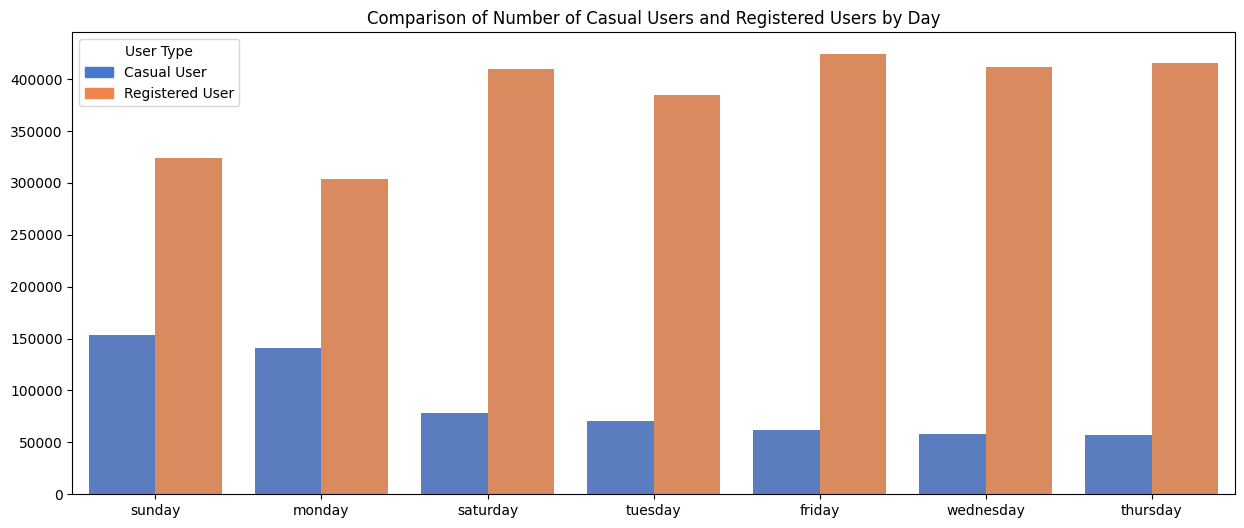

In [252]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

sns.barplot(x="day", y="user_count", hue="user_type", data=daily_user_type, palette="muted")
plt.ylabel(None)
plt.xlabel(None)
plt.title("Comparison of Number of Casual Users and Registered Users by Day")
casual_patch = mpatches.Patch(color=sns.color_palette("muted")[0], label='Casual User')
registered_patch = mpatches.Patch(color=sns.color_palette("muted")[1], label='Registered User')
plt.legend(handles=[casual_patch, registered_patch], title="User Type")
plt.show()

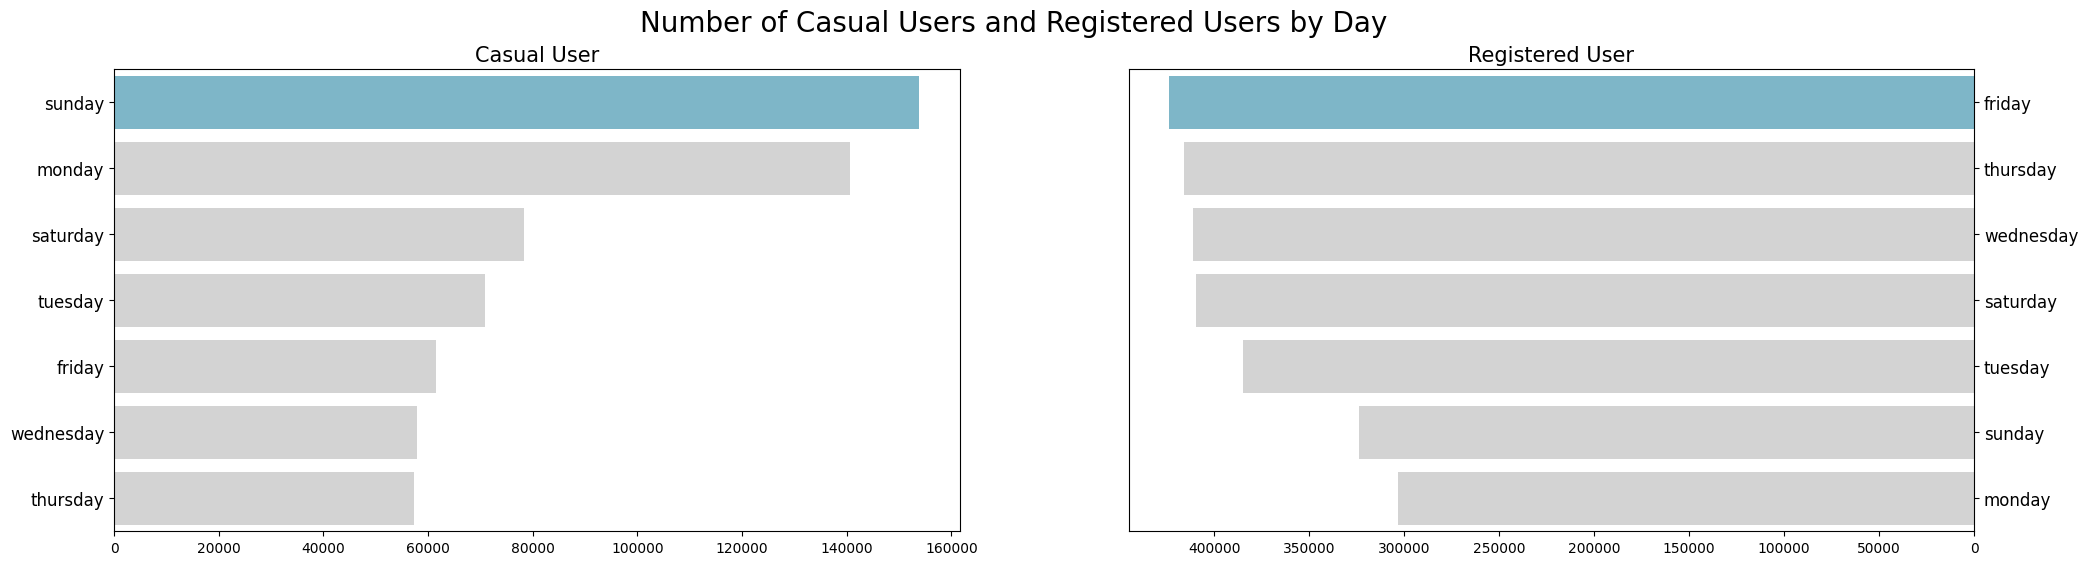

In [253]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(x="casual_user", y="day", data=sum_casual_user, palette=colors, hue="day", legend=False, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("Casual User", loc="center", fontsize=15)
ax[0].tick_params(axis ='y', labelsize=12)

sns.barplot(x="registered_User", y="day", data=sum_registered_User, hue="day", legend=False, palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Registered User", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)

plt.suptitle("Number of Casual Users and Registered Users by Day", fontsize=20)
plt.show()

From the visualisation above, it can be seen that every day Bike Sharing users with the type "registered user" have more numbers than users with the type "casual user".

When viewed based on each type of user, users with the type "casual user" are most numerous on Sundays with a total of 153,852 users. Meanwhile, users of the "registered_user" type are most numerous on Friday with a total of 423,935 users.

**Bike Sharing Productivity Based on Time (Question 2)**

In [254]:
sum_casual_user = hour_df.groupby(by=["hour", "workingday"]).casual.max("total_user").sort_values(ascending=False).reset_index()
sum_casual_user

,hour,workingday,casual
0,16,weekend/holiday,367
1,12,weekend/holiday,362
2,14,weekend/holiday,361
3,15,weekend/holiday,357
4,13,weekend/holiday,355
5,17,weekend/holiday,347
6,11,weekend/holiday,268
7,18,weekend/holiday,266
8,17,working day,264
9,14,working day,240


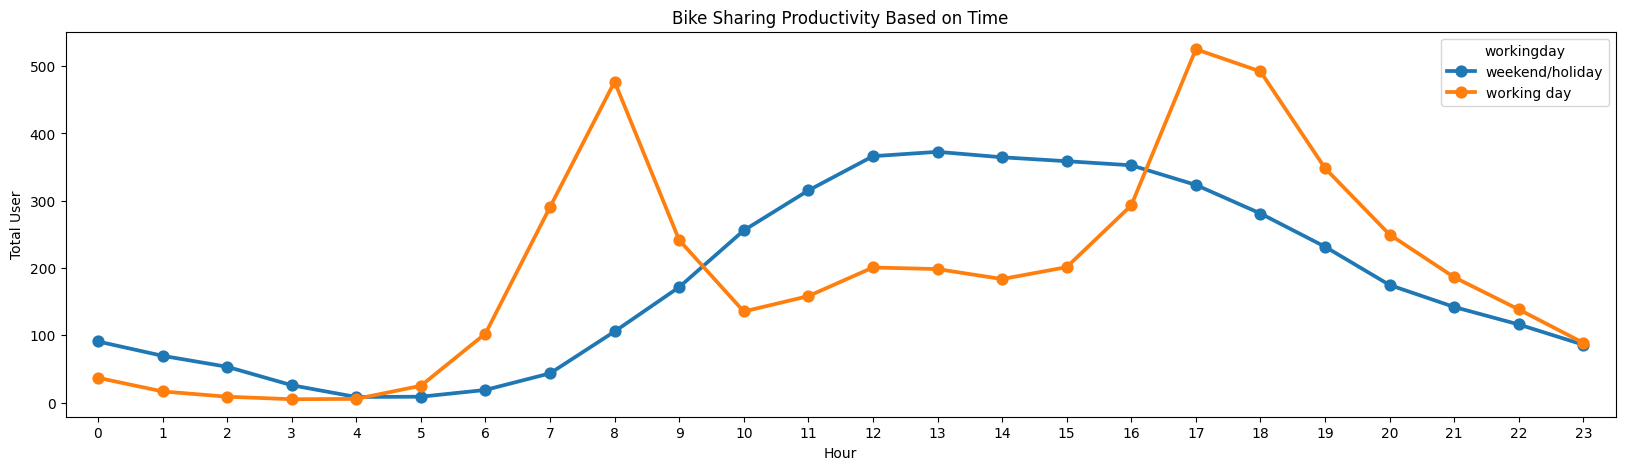

In [255]:
fig, ax = plt.subplots(figsize=(20,5))
sns.pointplot(data=hour_df, x='hour', y='total_user', hue='workingday', errorbar=None, ax=ax)
ax.set(title='Bike Sharing Productivity Based on Time')
ax.set_ylabel('Total User')
ax.set_xlabel('Hour')
plt.show()

In [256]:
sum_registered = hour_df.groupby(by=["hour" , "workingday"]).registered_User.max().sort_values(ascending=False).reset_index()
sum_registered

,hour,workingday,registered_User
0,18,working day,886
1,17,working day,885
2,8,working day,808
3,19,working day,662
4,17,weekend/holiday,601
5,18,weekend/holiday,589
6,7,working day,572
7,8,weekend/holiday,549
8,12,weekend/holiday,526
9,14,working day,502


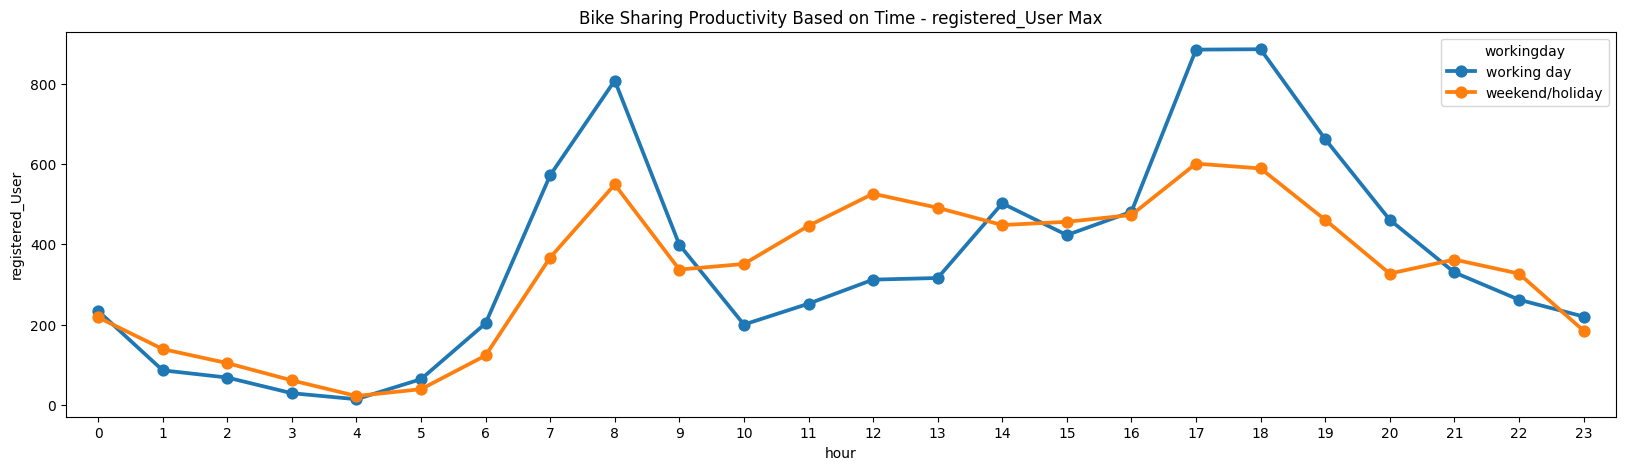

In [257]:
fig, ax = plt.subplots(figsize=(20,5))
sns.pointplot(data=sum_registered, x='hour', y='registered_User', hue='workingday', errorbar=None, ax=ax)
ax.set(title='Bike Sharing Productivity Based on Time - registered_User Max')
ax.set_ylabel('registered_User')
ax.set_xlabel('hour')
plt.show()

In [258]:
sum_total_user = hour_df.groupby(by=["hour" , "workingday"]).total_user.max().sort_values(ascending=False).reset_index()
sum_total_user

,hour,workingday,total_user
0,18,working day,977
1,17,working day,976
2,8,working day,839
3,16,weekend/holiday,783
4,12,weekend/holiday,776
5,13,weekend/holiday,760
6,15,weekend/holiday,750
7,14,weekend/holiday,750
8,19,working day,743
9,17,weekend/holiday,731


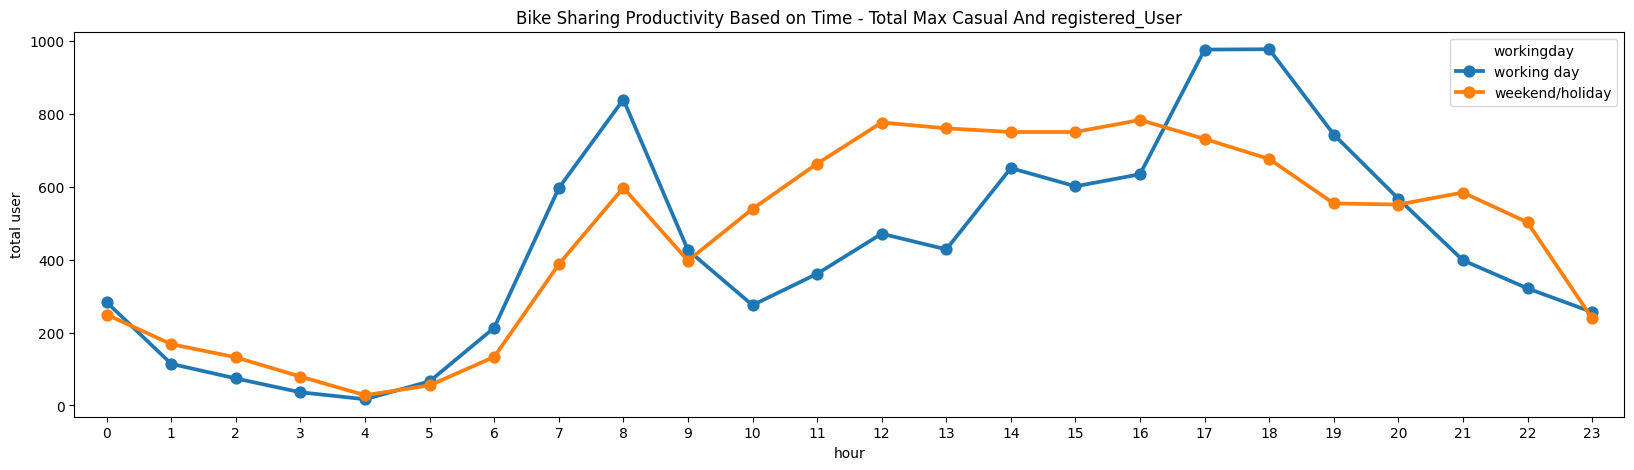

In [259]:
fig, ax = plt.subplots(figsize=(20,5))
sns.pointplot(data=sum_total_user, x='hour', y='total_user', hue='workingday', errorbar=None, ax=ax)
ax.set(title='Bike Sharing Productivity Based on Time - Total Max Casual And registered_User')
ax.set_ylabel('total user')
ax.set_xlabel('hour')
plt.show()

On weekends or holidays, the number of users starts to increase at 6.00 am and continues to increase until the peak number of users occurs at 1.00 pm. From 4.00pm the number of users starts to decline until 5.00am.

While on weekdays the number of users experienced a significant increase during the hours of leaving and returning from work, namely from 6.00 to 8.00 am and 15.00 to 17.00 pm. While a significant decrease in users occurs at 9.00 am when people are already actively working in the office and at night starting at 7.00 pm. The number of users tends to be low from midnight to 5 am

**Bike Sharing Productivity by Month (Question 3)**

In [260]:
sum_casual_user = day_df.groupby(by=["years", "month"]).casual_user.max().sort_values(ascending=False).reset_index()
sum_casual_user

,years,month,casual_user
0,2012,may,3410
1,2012,april,3252
2,2012,september,3160
3,2012,march,3155
4,2011,july,3065
5,2012,october,3031
6,2012,june,2963
7,2012,august,2827
8,2012,july,2562
9,2011,september,2521


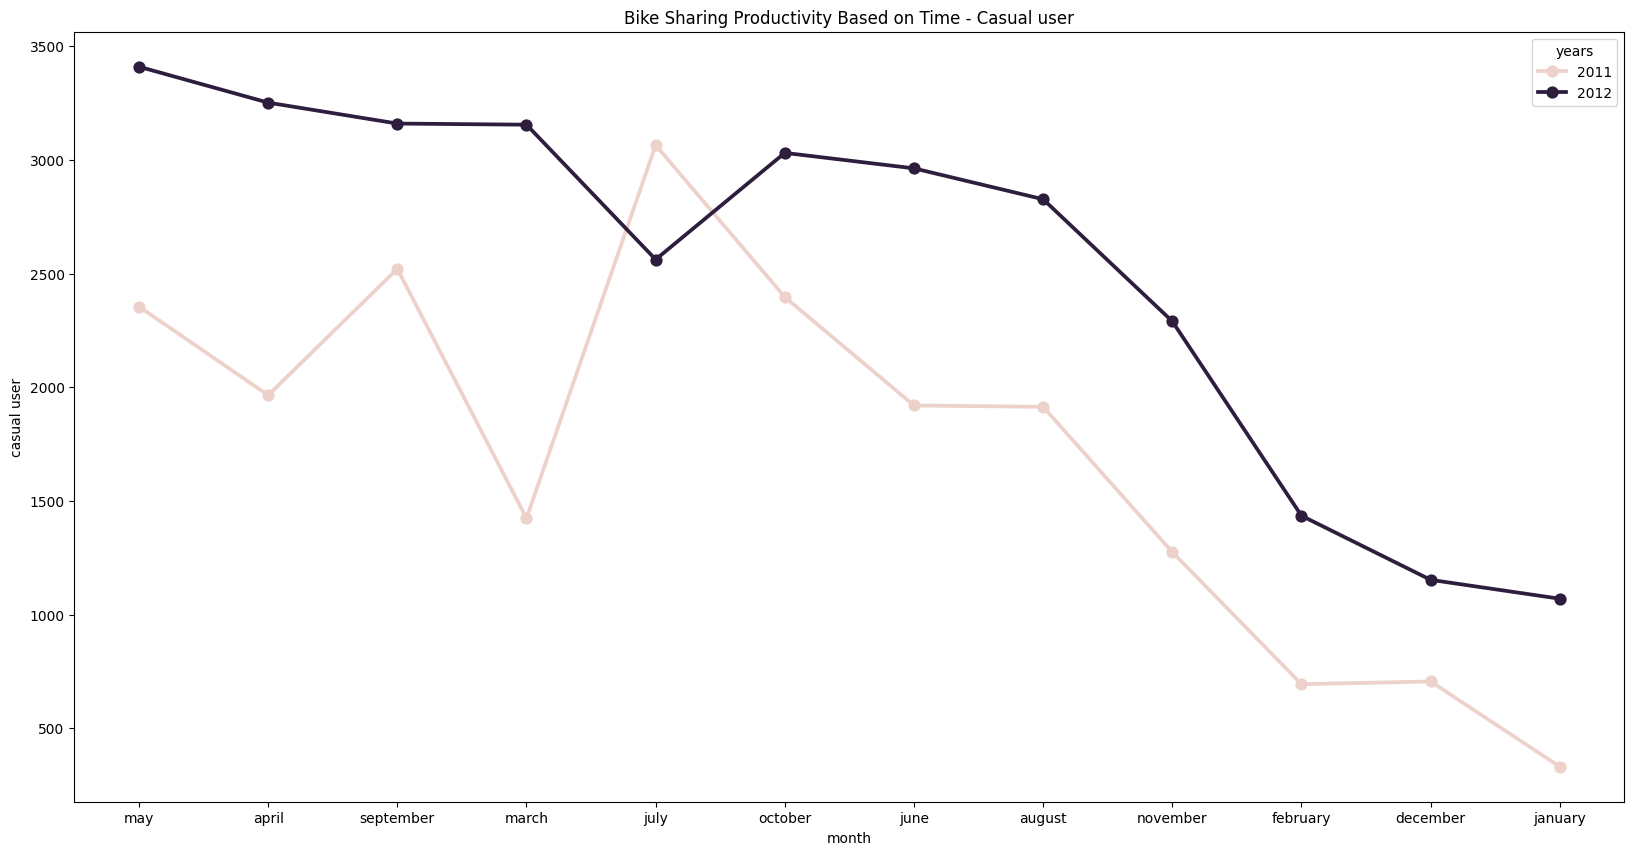

In [261]:
fig, ax = plt.subplots(figsize=(20,10))
sns.pointplot(data=sum_casual_user, x='month', y='casual_user', hue='years', errorbar=None, ax=ax)
ax.set(title='Bike Sharing Productivity Based on Time - Casual user')
ax.set_ylabel('casual user')
ax.set_xlabel('month')
plt.show()

In [262]:
sum_registered_user = day_df.groupby(by=["years", "month"]).registered_User.max().sort_values(ascending=False).reset_index()
sum_registered_user

,years,month,registered_User
0,2012,september,6946
1,2012,october,6911
2,2012,july,6790
3,2012,august,6541
4,2012,june,6456
5,2012,may,6433
6,2012,december,6055
7,2012,april,5950
8,2012,march,5893
9,2012,november,5520


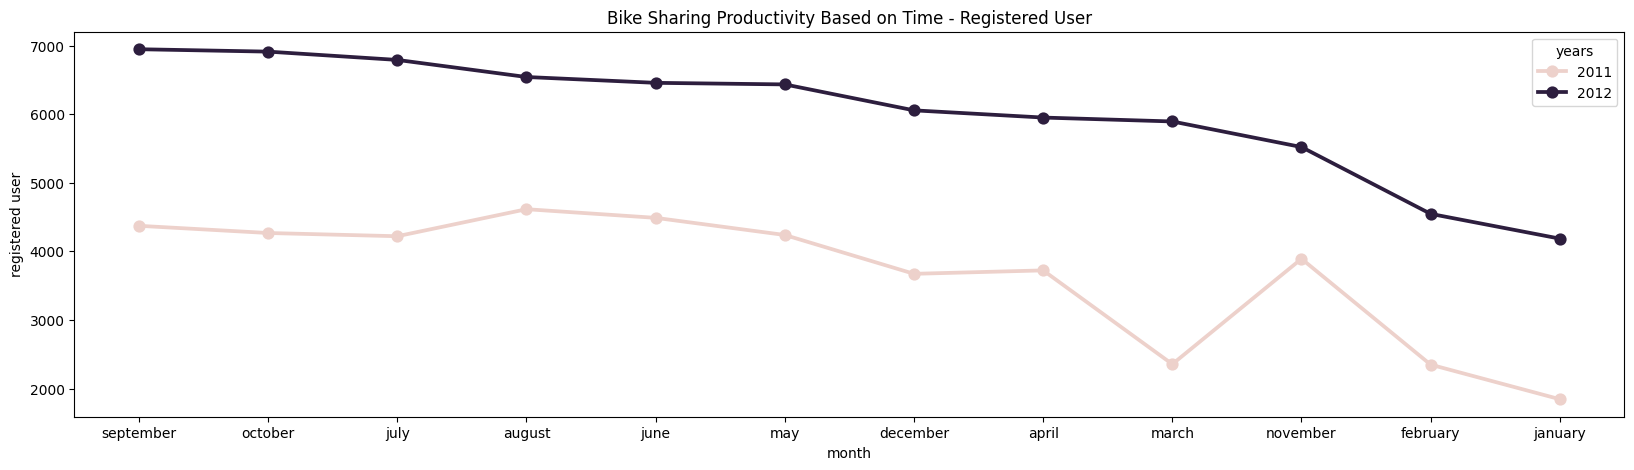

In [263]:
fig, ax = plt.subplots(figsize=(20,5))
sns.pointplot(data=sum_registered_user, x='month', y='registered_User', hue='years', errorbar=None, ax=ax)
ax.set(title='Bike Sharing Productivity Based on Time - Registered User')
ax.set_ylabel('registered user')
ax.set_xlabel('month')
plt.show()

In [264]:
sum_total_user = day_df.groupby(by=["years", "month"]).total_user.max().sort_values(ascending=False).reset_index()
sum_total_user

,years,month,total_user
0,2012,september,8714
1,2012,march,8362
2,2012,may,8294
3,2012,july,8173
4,2012,october,8156
5,2012,june,8120
6,2012,august,7865
7,2012,april,7460
8,2012,november,6852
9,2012,december,6606


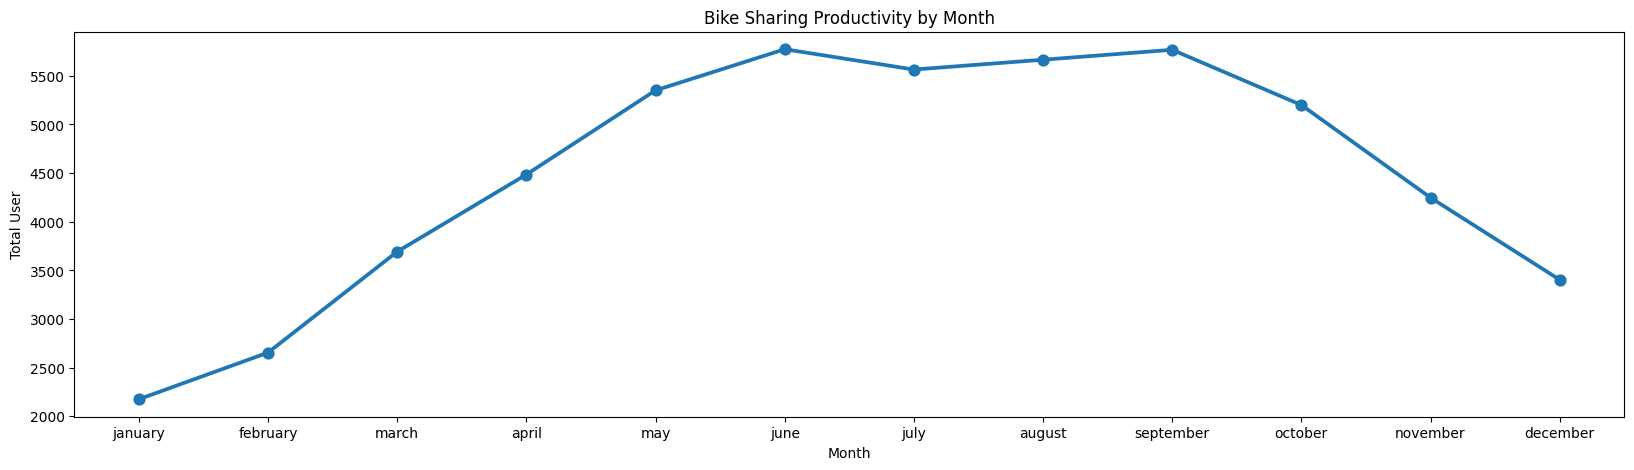

In [265]:
fig, ax = plt.subplots(figsize=(20,5))
sns.pointplot(data=day_df, x='month', y='total_user', errorbar=None, ax=ax)
ax.set(title='Bike Sharing Productivity by Month')
ax.set_ylabel('Total User')
ax.set_xlabel('Month')
plt.show()

Bike Sharing has a very high productivity in June and September with many users renting bicycles in these months. While starting in October the number of users continued to decline until the lowest point in January. The number of users increased again starting in February.

**Weather and Season Impact on Bike Sharing Productivity (Question 4)**

In [266]:
byweather = hour_df.groupby("weather").total_user.sum().sort_values(ascending=False).reset_index()
byweather

,weather,total_user
0,clear,2338173
1,mist,795952
2,light snow,158331
3,heavy rain,223


In [267]:
byseason = hour_df.groupby("season").total_user.sum().sort_values(ascending=False).reset_index()
byseason

,season,total_user
0,fall,1061129
1,summer,918589
2,winter,841613
3,springer,471348


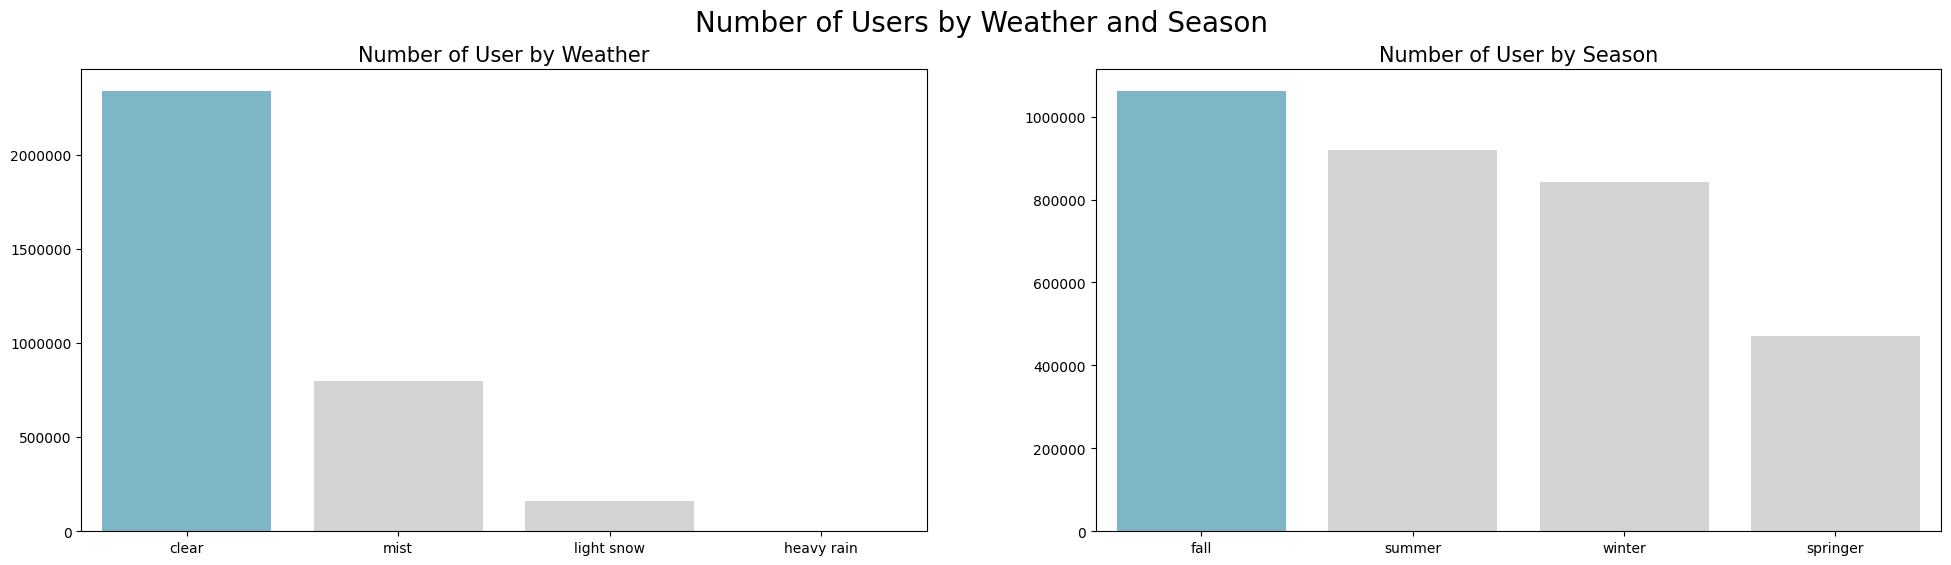

In [268]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 6))
colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(y="total_user", x="weather", data=byweather.sort_values(by="total_user", ascending=False), palette=colors, hue="weather", legend=False, ax=ax[0])
ax[0].set_title("Number of User by Weather", loc="center", fontsize=15)
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].ticklabel_format(style='plain', axis='y')

sns.barplot(y="total_user", x="season", data=byseason.sort_values(by="total_user", ascending=False), palette=colors, hue="season", legend=False, ax=ax[1])
ax[1].set_title("Number of User by Season", loc="center", fontsize=15)
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].ticklabel_format(style='plain', axis='y')

plt.suptitle("Number of Users by Weather and Season", fontsize=20)
plt.show()

Based on weather conditions, Bike Sharing has a very high productivity during sunny or slightly cloudy weather with 2,338,173 users. While in times of heavy rain, storms, snow, or fog Bike Sharing productivity is very low with only 223 users.

When viewed by season, the highest productivity occurs in autumn with a total of 1,061,129 users. While the lowest productivity occurred in spring with 471,348 users.

## RFM ANALYSIS

In [269]:
rfm_df = day_df.groupby(by="day", as_index=False).agg({
    "date": "max", # retrieve the date of the last order
    "instant": "nunique", # calculate the order quantity
    "total_user": "sum" # calculate the amount of revenue generated
})

rfm_df.columns = ["day", "max_order_timestamp", "frequency", "monetary"]

# calculates when the customer last made a transaction (days)
rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date
recent_date = day_df["date"].dt.date.max()
rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(lambda x: (recent_date - x).days)

rfm_df.drop("max_order_timestamp", axis=1, inplace=True)
rfm_df

,day,frequency,monetary,recency
0,friday,104,485395,4
1,monday,105,444027,1
2,saturday,104,487790,3
3,sunday,105,477807,2
4,thursday,104,473048,5
5,tuesday,105,455503,0
6,wednesday,104,469109,6


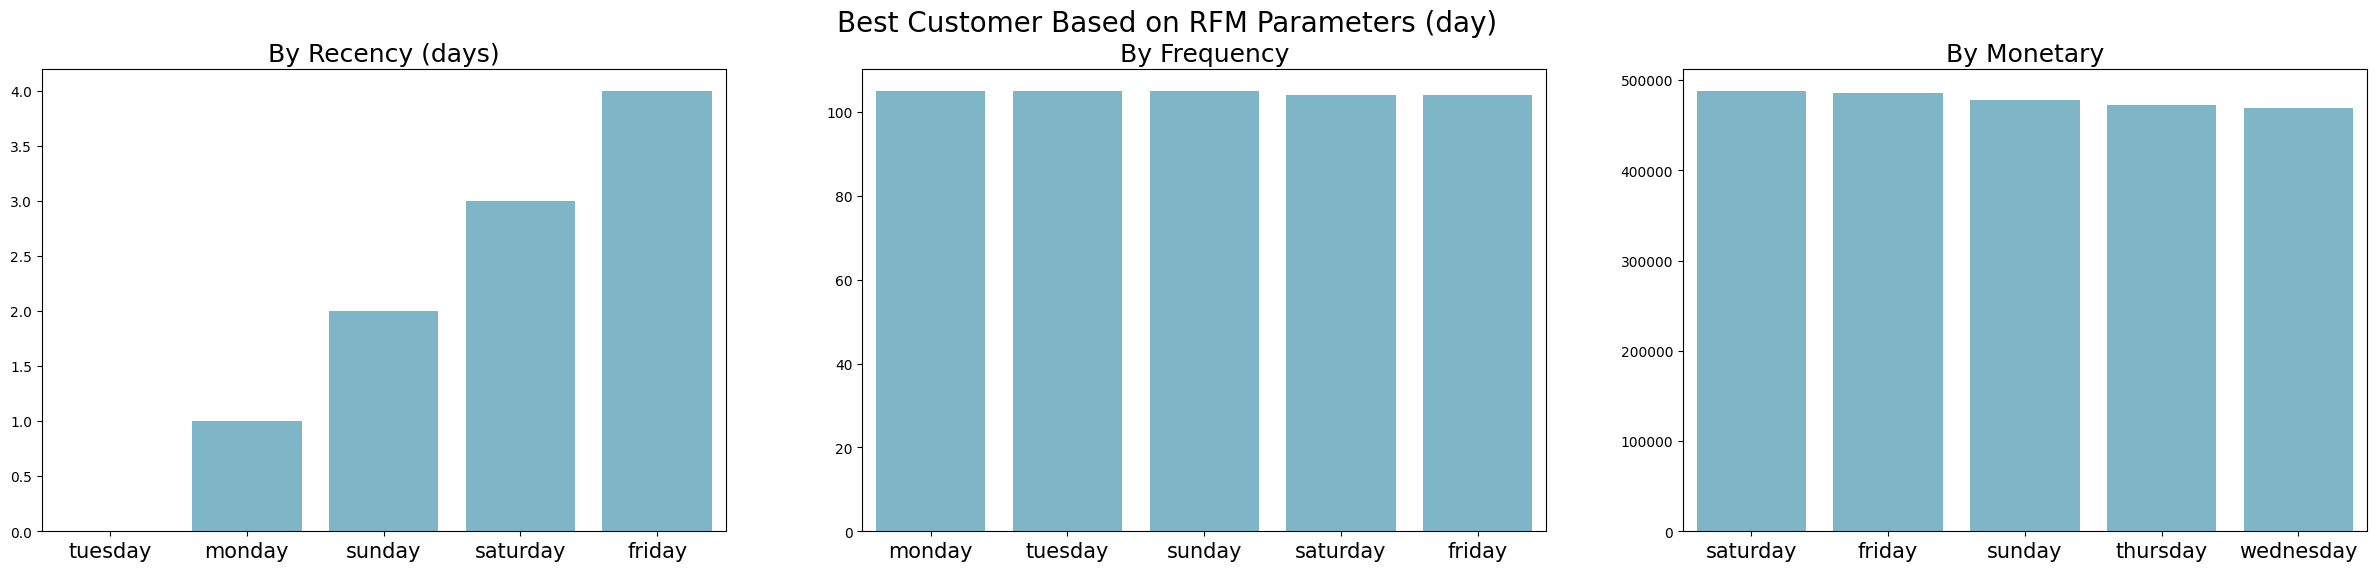

In [270]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 6))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

sns.barplot(y="recency", x="day", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, hue="day", legend=False, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)
ax[0].tick_params(axis ='x', labelsize=15)

sns.barplot(y="frequency", x="day", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, hue="day", legend=False, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)
ax[1].tick_params(axis='x', labelsize=15)

sns.barplot(y="monetary", x="day", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, hue="day", legend=False, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary", loc="center", fontsize=18)
ax[2].tick_params(axis='x', labelsize=15)

plt.suptitle("Best Customer Based on RFM Parameters (day)", fontsize=20)
plt.show()

## Conclusion

Kesimpulan

Secara keseluruhan, jumlah pengguna terdaftar (2.672.662) lebih banyak daripada pengguna kasual (620.017).
Jumlah pengguna terdaftar tertinggi terjadi pada hari Jumat, dengan 423.935 pengguna terdaftar, sedangkan jumlah pengguna kasual tertinggi terjadi pada hari Minggu, dengan 323.955 pengguna kasual.
Jumlah pengguna terdaftar terendah terjadi pada hari Senin, dengan 303.506 pengguna terdaftar.
Jumlah pengguna kasual terendah terjadi pada hari Kamis, dengan 57.319 pengguna kasual.
Seberapa produktif pengguna registered dan kasual Bike Sharing dalam 24 jam?
Pada hari kerja:
Jumlah Pengguna terdaftar tertinggi pada jam 18:00,dengan jumlah pengguna terdaftar 886.
Jumlah Pengguna kasual tertinggi pada jam 17:00,dengan jumlah kasual 264.
Jumlah pengguna terdaftar terendah pada jam 04:00,dengan jumlah kasual 14.
Jumlah pengguna kasual terendah pada jam 05:00,dengan jumlah kasual 10.
Pada hari libur/akhir pekan:
jumlah pengguna terdaftar tertinggi pada jam 17:00,dengan jumlah pengguna terdaftar 601.
Jumlah pengguna kasual tertinggi pada jam 16:00,dengan jumlah pengguna kasual 367.
Jumlah pengguna terdaftar terendah pada jam 04:00,dengan jumlah pengguna terdaftar 22.
Jumlah pengguna kasual terendah pada jam 04:00,dengan jumlah pengguna kasual 22.
3. Seberapa produktifivitas pengguna layanan berbagi sepeda terdaftar dan kasual secara bulanan dan tahun?
pada tahun 2011 :
Jumlah pengguna terdaftar tertinggi pada tahun 2011,pada bulan agustus,dengan jumlah pengguna terdaftar 4614.
Jumlah pengguna kasual tertinggi pada tahun 2011,pada bulan  september,dengan jumlah pengguna kasual 2521.
Jumlah pengguna terdaftar terendah pada tahun 2011,pada bulan januari,dengan jumlah pengguna terdaftar 1844.
Jumlah Pengguna kasual terendah pada tahun 2011,pada bulan  januari,dengan jumlah pengguna kasual 331.
pada tahun 2012 :
Jumlah pengguna terdaftar tertinggi pada tahun 2012,pada bulan september,dengan jumlah pengguna terdaftar 6946.
Jumlah pengguna kasual tertinggi pada tahun 2012,pada bulan  may,dengan jumlah pengguna kasual 3410.
Jumlah pengguna terdaftar terendah pada tahun 2012,pada bulan januari,dengan jumlah pengguna terdaftar 4185.
Jumlah Pengguna kasual terendah pada tahun 2012,pada bulan  januari,dengan jumlah pengguna kasual 1070.
Berdasarkan kondisi cuaca:
Bike Sharing memiliki produktivitas yang sangat tinggi selama cuaca cerah atau sedikit berawan dengan 2.338.173 pengguna. Sementara pada saat hujan deras, badai, salju, atau kabut, produktivitas Bike Sharing sangat rendah dengan hanya 223 pengguna.
Jika dilihat berdasarkan musim, produktivitas tertinggi terjadi pada musim gugur dengan total 1.061.129 pengguna. Sedangkan produktivitas terendah terjadi pada musim semi dengan 471.348 pengguna.

Export Clean Dataset

In [272]:
day_df.to_csv("Dasboard/day_clean.csv", index=False)